# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** M Fahril Luthfi
- **Email:** mfahrilluthfi@gmail.com
- **ID Dicoding:** m_fahril_luthfit7lm

## Pendahuluan

Sistem *bike sharing* adalah generasi baru penyewaan sepeda: proses keanggotaan, peminjaman, dan pengembalian berlangsung otomatis. Permintaan penyewaan sangat dipengaruhi **waktu** (jam, hari kerja/libur) dan **lingkungan** (cuaca, musim). Bagi operator, memahami pola ini penting untuk menentukan *kapan* dan *di mana* sepeda harus tersedia.

Proyek ini menganalisis **Bike Sharing Dataset** (Capital Bikeshare, Washington D.C., periode **1 Januari 2011 – 31 Desember 2012**) menggunakan **dua file dataset**: data per jam (`data_1.csv`, analisis utama) dan data harian (`data_2.csv`, untuk validasi silang dan analisis tingkat harian). Alur analisis mengikuti template resmi: *Business Questions → Data Wrangling → EDA → Visualization & Explanatory Analysis → Analisis Lanjutan → Conclusion & Recommendation*.

**Prinsip kerja:** seluruh angka pada notebook ini dihitung langsung oleh Python dari dataset; tidak ada angka yang diketik manual pada tahap analisis.

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

**Pertanyaan bisnis yang dipilih (berdasarkan hasil pemeriksaan dataset)**

Dataset mencakup 731 hari (2011–2012) dengan 17.379 baris per jam. Kolom `hr`, `workingday`, `weathersit`, dan `season` terisi lengkap, sehingga kedua pertanyaan berikut dapat dijawab langsung dari data. Keduanya sengaja dipilih dari sudut pandang berbeda: **BQ1 = dimensi waktu (operasional harian)**, **BQ2 = dimensi lingkungan (cuaca & musim)**.

- **Business Question 1 (Pola Jam Puncak Penyewaan Sepeda pada Working Day vs Non-Working Day):** Pada jam berapa rata-rata penyewaan sepeda per jam mencapai puncak pada *working day* dibandingkan *non-working day*, dan berapa rata-rata penyewaan pada jam puncak tersebut, selama periode Januari 2011 – Desember 2012, sehingga operator dapat menjadwalkan redistribusi dan ketersediaan sepeda pada jam-jam kritis?
- **Business Question 2 (Dampak Cuaca Buruk dan Musim terhadap Penyewaan Sepeda):** Berapa persen penurunan rata-rata penyewaan sepeda per jam pada kondisi cuaca buruk (*Mist/Cloudy* dan *Light Rain/Snow*) dibandingkan cuaca cerah, dan pada musim apa penurunan akibat hujan/salju paling besar, selama Januari 2011 – Desember 2012, sehingga operator dapat menyusun strategi promosi dan perawatan armada berdasarkan musim dan cuaca?

**Pengecekan SMART**

| Elemen | BQ1 | BQ2 |
|---|---|---|
| Specific | Jam puncak, dibedakan working vs non-working day | Dampak cuaca buruk, dibedakan per musim |
| Measurable | Rata-rata `cnt` per jam | Persentase penurunan rata-rata `cnt` |
| Action-Oriented | Jadwal redistribusi sepeda & staf | Promosi, kapasitas, dan perawatan armada per musim/cuaca |
| Relevant | Efisiensi operasional bike sharing | Perencanaan permintaan & pendapatan |
| Time-bound | Jan 2011 – Des 2012 | Jan 2011 – Des 2012 |

## Import Semua Packages/Library yang Digunakan

**Tujuan:** memuat seluruh library di satu tempat agar notebook dapat dijalankan dari atas ke bawah tanpa dependensi tersembunyi.
- `pandas`, `numpy` untuk manipulasi dan agregasi data
- `matplotlib`, `seaborn` untuk visualisasi

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

## Data Wrangling

### Gathering Data

**Tujuan:** memuat kedua dataset, yaitu data per jam (`data_1.csv`) dan data harian (`data_2.csv`), dan memastikan keduanya terbaca dengan benar.
**Proses:** `pd.read_csv` dengan path relatif `data/` (struktur folder submission). Jika dijalankan di Google Colab, unggah `data_1.csv` dan `data_2.csv` ke direktori kerja; kode otomatis mencoba path alternatif.
**Penamaan file:** `data_1.csv` adalah data per jam (nama asli dataset: `hour.csv`) dan `data_2.csv` adalah data harian (nama asli: `day.csv`); isinya tidak diubah.
**Peran masing-masing file:** `data_1.csv` menjadi sumber analisis utama (pola per jam untuk BQ1 dan BQ2). `data_2.csv` dipakai untuk memvalidasi konsistensi data per jam dan untuk menguji ulang BQ2 pada tingkat harian.

#### Load hour_df dan day_df

In [2]:
def find_path(filename):
    # Path relatif (portable). Fallback: file berada di direktori yang sama dengan notebook (mis. Colab).
    for p in (f'data/{filename}', filename):
        if os.path.exists(p):
            return p
    raise FileNotFoundError(f"{filename} tidak ditemukan. Letakkan di folder data/ atau di folder yang sama dengan notebook.")

HOUR_PATH = find_path('data_1.csv')
DAY_PATH = find_path('data_2.csv')

hour_df = pd.read_csv(HOUR_PATH)
day_df = pd.read_csv(DAY_PATH)

print(f'hour_df ({HOUR_PATH}): {hour_df.shape[0]:,} baris x {hour_df.shape[1]} kolom')
print(f'day_df  ({DAY_PATH}) : {day_df.shape[0]:,} baris x {day_df.shape[1]} kolom')
hour_df.head()

hour_df (data/data_1.csv): 17,379 baris x 17 kolom
day_df  (data/data_2.csv) : 731 baris x 16 kolom


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.29,0.81,0.00,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.27,0.80,0.00,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.27,0.80,0.00,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.29,0.75,0.00,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.29,0.75,0.00,0,1,1


In [3]:
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.34,0.36,0.81,0.16,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.36,0.35,0.70,0.25,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.20,0.19,0.44,0.25,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.20,0.21,0.59,0.16,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.23,0.23,0.44,0.19,82,1518,1600


In [4]:
print('Kolom hour_df:', list(hour_df.columns))
print('Kolom yang hanya ada di hour_df:', sorted(set(hour_df.columns) - set(day_df.columns)))
print('Kolom yang hanya ada di day_df :', sorted(set(day_df.columns) - set(hour_df.columns)))
print(f"Rentang tanggal hour_df: {hour_df['dteday'].min()} s.d. {hour_df['dteday'].max()}")
print(f"Rentang tanggal day_df : {day_df['dteday'].min()} s.d. {day_df['dteday'].max()}")

Kolom hour_df: ['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']
Kolom yang hanya ada di hour_df: ['hr']
Kolom yang hanya ada di day_df : []
Rentang tanggal hour_df: 2011-01-01 s.d. 2012-12-31
Rentang tanggal day_df : 2011-01-01 s.d. 2012-12-31


**Insight:**
- `hour_df` berisi 17.379 baris (per jam) dan `day_df` berisi 731 baris (per hari); keduanya 2 tahun penuh, 1 Januari 2011 sampai 31 Desember 2012.
- Struktur kolom sama, kecuali kolom `hr` yang hanya ada di `hour_df`. Karena itu `day_df` dapat dipakai sebagai pembanding agregat harian dari `hour_df`.
- Variabel kategorikal (`season`, `weathersit`, `yr`, dst.) masih berupa kode angka sehingga perlu diberi label agar mudah dibaca.

### Assessing Data

**Tujuan:** menilai kualitas data secara jujur: hanya melaporkan masalah yang benar-benar terbukti dari pemeriksaan.
**Proses:** pemeriksaan struktur, missing value, duplikat, statistik deskriptif, konsistensi antar kolom, kelengkapan data per jam, dan nilai tidak valid.

#### Identifying structure, missing values, and duplicates

In [5]:
hour_df.info()
print('\nMissing value per kolom:')
print(hour_df.isna().sum())
print(f'\nJumlah baris duplikat      : {hour_df.duplicated().sum()}')
print(f"Jumlah instant duplikat    : {hour_df['instant'].duplicated().sum()}")

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  str    
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), str(1)
memory usage: 2.4 MB

Missing value per kolom:
instant       0
dteday        0
season

In [6]:
hour_df.describe().T

,count,mean,std,min,25%,50%,75%,max
instant,"17,379.00","8,690.00","5,017.03",1.00,"4,345.50","8,690.00","13,034.50","17,379.00"
season,"17,379.00",2.50,1.11,1.00,2.00,3.00,3.00,4.00
yr,"17,379.00",0.50,0.50,0.00,0.00,1.00,1.00,1.00
mnth,"17,379.00",6.54,3.44,1.00,4.00,7.00,10.00,12.00
hr,"17,379.00",11.55,6.91,0.00,6.00,12.00,18.00,23.00
holiday,"17,379.00",0.03,0.17,0.00,0.00,0.00,0.00,1.00
weekday,"17,379.00",3.00,2.01,0.00,1.00,3.00,5.00,6.00
workingday,"17,379.00",0.68,0.47,0.00,0.00,1.00,1.00,1.00
weathersit,"17,379.00",1.43,0.64,1.00,1.00,1.00,2.00,4.00
temp,"17,379.00",0.50,0.19,0.02,0.34,0.50,0.66,1.00


In [7]:
print('Jumlah nilai unik per kolom:')
print(hour_df.nunique())
print('\nDistribusi weathersit:')
print(hour_df['weathersit'].value_counts().sort_index())

Jumlah nilai unik per kolom:
instant       17379
dteday          731
season            4
yr                2
mnth             12
hr               24
holiday           2
weekday           7
workingday        2
weathersit        4
temp             50
atemp            65
hum              89
windspeed        30
casual          322
registered      776
cnt             869
dtype: int64

Distribusi weathersit:
weathersit
1    11413
2     4544
3     1419
4        3
Name: count, dtype: int64


**Hasil pemeriksaan awal (jujur):**
- **Tidak ada missing value** pada seluruh 17 kolom.
- **Tidak ada baris duplikat** dan `instant` unik.
- Rentang nilai fitur ter-normalisasi (`temp`, `atemp`, `hum`, `windspeed`) berada pada 0–1 sehingga sesuai dokumentasi.
- Berikut pemeriksaan lanjutan untuk menemukan masalah yang tidak terlihat dari `info()` dan `describe()`.

#### Identifying problem 1: tipe data tanggal

In [8]:
print('Tipe data dteday :', hour_df['dteday'].dtype)
print('Contoh nilai      :', hour_df['dteday'].iloc[0], '->', type(hour_df['dteday'].iloc[0]).__name__)

Tipe data dteday : str
Contoh nilai      : 2011-01-01 -> str


#### Identifying problem 2: kelengkapan data per jam

In [9]:
n_days = hour_df['dteday'].nunique()
expected_rows = n_days * 24
missing_rows = expected_rows - len(hour_df)

rows_per_day = hour_df.groupby('dteday').size()
days_incomplete = (rows_per_day < 24).sum()

print(f'Jumlah hari unik            : {n_days}')
print(f'Baris seharusnya (hari x 24): {expected_rows:,}')
print(f'Baris aktual                : {len(hour_df):,}')
print(f'Baris jam yang hilang       : {missing_rows}')
print(f'Hari dengan < 24 jam data   : {days_incomplete} dari {n_days} hari')

print('\nJumlah record per jam (hr):')
print(hour_df.groupby('hr').size().to_string())

Jumlah hari unik            : 731
Baris seharusnya (hari x 24): 17,544
Baris aktual                : 17,379
Baris jam yang hilang       : 165
Hari dengan < 24 jam data   : 76 dari 731 hari

Jumlah record per jam (hr):
hr
0     726
1     724
2     715
3     697
4     697
5     717
6     725
7     727
8     727
9     727
10    727
11    727
12    728
13    729
14    729
15    729
16    730
17    730
18    728
19    728
20    728
21    728
22    728
23    728


#### Identifying problem 3: nilai kelembapan tidak valid

In [10]:
zero_hum = hour_df[hour_df['hum'] == 0]
print(f'Baris dengan hum == 0 : {len(zero_hum)}')
print('Tanggal terdampak      :', zero_hum['dteday'].unique())
print(f"Nilai hum minimum (selain 0): {hour_df.loc[hour_df['hum'] > 0, 'hum'].min():.2f}")

Baris dengan hum == 0 : 22
Tanggal terdampak      : <ArrowStringArray>
['2011-03-10']
Length: 1, dtype: str
Nilai hum minimum (selain 0): 0.08


#### Identifying problem 4: label `season` tidak sesuai tanggal

In [11]:
tmp = hour_df.copy()
tmp['dteday'] = pd.to_datetime(tmp['dteday'])

print('Rentang bulan-hari untuk setiap kode season:')
season_range = tmp.groupby('season')['dteday'].agg(
    bulan_terkecil=lambda s: s.dt.month.min(),
    bulan_terbesar=lambda s: s.dt.month.max())
print(season_range)

print('\nTanggal awal & akhir tiap musim (data 2011):')
print(tmp[tmp['yr'] == 0].groupby('season')['dteday'].agg(['min', 'max']))

print('\nJumlah record Januari per season:')
print(tmp[tmp['mnth'] == 1]['season'].value_counts())

Rentang bulan-hari untuk setiap kode season:


        bulan_terkecil  bulan_terbesar
season                                
1                    1              12
2                    3               6
3                    6               9
4                    9              12

Tanggal awal & akhir tiap musim (data 2011):
              min        max
season                      
1      2011-01-01 2011-12-31
2      2011-03-21 2011-06-20
3      2011-06-21 2011-09-22
4      2011-09-23 2011-12-20

Jumlah record Januari per season:
season
1    1429
Name: count, dtype: int64


#### Pemeriksaan konsistensi, outlier, dan kategori langka

In [12]:
tmp['dow_pandas'] = (tmp['dteday'].dt.dayofweek + 1) % 7   # Senin=1 ... Minggu=0 (mengikuti skema dataset)

checks = {
    'cnt == casual + registered (semua baris)'    : bool((hour_df['cnt'] == hour_df['casual'] + hour_df['registered']).all()),
    'weekday sesuai tanggal (semua baris)'        : bool((tmp['dow_pandas'] == tmp['weekday']).all()),
    'yr sesuai tahun pada tanggal (semua baris)'  : bool(((tmp['dteday'].dt.year - 2011) == tmp['yr']).all()),
    'mnth sesuai bulan pada tanggal (semua baris)': bool((tmp['dteday'].dt.month == tmp['mnth']).all()),
    'tidak ada akhir pekan berstatus workingday'  : not bool(((tmp['weekday'].isin([0, 6])) & (tmp['workingday'] == 1)).any()),
    'tidak ada hari libur berstatus workingday'   : not bool(((tmp['holiday'] == 1) & (tmp['workingday'] == 1)).any()),
}
for k, v in checks.items():
    print(f"{'OK  ' if v else 'GAGAL'} | {k}")

q1, q3 = hour_df['cnt'].quantile([0.25, 0.75])
upper = q3 + 1.5 * (q3 - q1)
n_out = (hour_df['cnt'] > upper).sum()
print(f'\nOutlier cnt (IQR): batas atas = {upper:.1f}; jumlah baris di atas batas = {n_out} ({n_out/len(hour_df):.1%})')
print(f"Jumlah baris weathersit = 4: {(hour_df['weathersit'] == 4).sum()}")

OK   | cnt == casual + registered (semua baris)
OK   | weekday sesuai tanggal (semua baris)
OK   | yr sesuai tahun pada tanggal (semua baris)
OK   | mnth sesuai bulan pada tanggal (semua baris)
OK   | tidak ada akhir pekan berstatus workingday
OK   | tidak ada hari libur berstatus workingday

Outlier cnt (IQR): batas atas = 642.5; jumlah baris di atas batas = 505 (2.9%)
Jumlah baris weathersit = 4: 3


#### Identifying problem 5: kualitas `day_df` dan konsistensinya dengan `hour_df`

`day_df` dinilai dengan pemeriksaan yang sama, lalu dibandingkan dengan agregat harian dari `hour_df` (validasi silang).

In [13]:
day_df.info()
print('\nMissing value total  :', int(day_df.isna().sum().sum()))
print('Baris duplikat       :', int(day_df.duplicated().sum()))
print('Tipe dteday          :', day_df['dteday'].dtype)

zero_hum_day = day_df[day_df['hum'] == 0]
print(f'\nBaris hum == 0 di day_df: {len(zero_hum_day)} -> tanggal {list(zero_hum_day["dteday"])}')
print('Distribusi weathersit di day_df:', day_df['weathersit'].value_counts().sort_index().to_dict())
print('cnt == casual + registered (semua baris):', bool((day_df['cnt'] == day_df['casual'] + day_df['registered']).all()))

d_tmp = day_df.assign(dteday=pd.to_datetime(day_df['dteday']))
print('\nTanggal awal & akhir tiap kode season di day_df (2011):')
print(d_tmp[d_tmp['yr'] == 0].groupby('season')['dteday'].agg(['min', 'max']))

<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    str    
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), str(1)
memory usage: 98.6 KB

Missing value total  : 0
Baris duplikat       : 0
Tipe dteday          : str

Baris hum == 0 di day_df: 1 -

In [14]:
# Validasi silang: total harian day_df vs jumlah per jam dari hour_df
hour_daily = hour_df.groupby('dteday').agg(cnt_hour=('cnt', 'sum'), casual_hour=('casual', 'sum'),
                                           registered_hour=('registered', 'sum'), jam_tercatat=('hr', 'size')).reset_index()
cmp = day_df.merge(hour_daily, on='dteday', how='outer', indicator=True)

print('Hari yang hanya ada di salah satu file :', int((cmp['_merge'] != 'both').sum()))
print('cnt harian == jumlah cnt per jam       :', bool((cmp['cnt'] == cmp['cnt_hour']).all()))
print('casual harian == jumlah casual per jam :', bool((cmp['casual'] == cmp['casual_hour']).all()))
print('registered harian == jumlah per jam    :', bool((cmp['registered'] == cmp['registered_hour']).all()))

incomplete = cmp[cmp['jam_tercatat'] < 24]
print(f"\nHari dengan < 24 jam tercatat : {len(incomplete)}")
print('Total harian tetap cocok pada hari-hari tersebut:', bool((incomplete['cnt'] == incomplete['cnt_hour']).all()))
print(f"Nilai cnt minimum pada hour_df : {hour_df['cnt'].min()} (tidak ada baris bernilai 0)")

missing_per_hr = (hour_df['dteday'].nunique() - hour_df.groupby('hr').size())
missing_per_hr = missing_per_hr[missing_per_hr > 0]
print(f"\nJam yang hilang 00-05: {int(missing_per_hr.loc[0:5].sum())} dari {int(missing_per_hr.sum())} baris")
print('Jumlah jam hilang per jam (hr):', missing_per_hr.to_dict())

Hari yang hanya ada di salah satu file : 0
cnt harian == jumlah cnt per jam       : True
casual harian == jumlah casual per jam : True
registered harian == jumlah per jam    : True

Hari dengan < 24 jam tercatat : 76
Total harian tetap cocok pada hari-hari tersebut: True
Nilai cnt minimum pada hour_df : 1 (tidak ada baris bernilai 0)

Jam yang hilang 00-05: 110 dari 165 baris
Jumlah jam hilang per jam (hr): {0: 5, 1: 7, 2: 16, 3: 34, 4: 34, 5: 14, 6: 6, 7: 4, 8: 4, 9: 4, 10: 4, 11: 4, 12: 3, 13: 2, 14: 2, 15: 2, 16: 1, 17: 1, 18: 3, 19: 3, 20: 3, 21: 3, 22: 3, 23: 3}


### Temuan Data Quality

1. **Kolom tanggal `dteday` bertipe teks (string/object) di kedua file**
   - Bukti: `dtype` kolom `dteday` pada `hour_df` dan `day_df` bukan `datetime64`; nilainya berupa string `'2011-01-01'`.
   - Dampak: tidak bisa dipakai untuk operasi waktu (rentang periode, filter tanggal, ekstraksi tahun/bulan) dan filter tanggal pada dashboard.
   - Tindakan: konversi ke `datetime64` dengan `pd.to_datetime` pada kedua DataFrame.

2. **Data per jam tidak lengkap: 165 jam tidak tercatat di `hour_df`**
   - Bukti: 731 hari seharusnya menghasilkan 17.544 baris, tetapi hanya ada 17.379 baris (**165 baris hilang** pada **76 dari 731 hari**). Sebanyak 110 dari 165 jam yang hilang berada pada jam 00-05. Validasi silang menunjukkan **total harian di `day_df` sama persis dengan jumlah per jam di `hour_df` pada seluruh 731 hari** (`cnt`, `casual`, `registered`), termasuk 76 hari yang tidak lengkap. Nilai `cnt` minimum di `hour_df` adalah 1 (tidak ada jam bernilai 0).
   - Interpretasi: bukti-bukti tersebut konsisten dengan dugaan bahwa jam yang hilang adalah **jam tanpa penyewaan (0) yang tidak dicatat**. Ini dugaan berbasis bukti dan tidak dikonfirmasi dokumentasi dataset.
   - Dampak: **total penyewaan tidak terpengaruh** (cocok dengan `day_df`), tetapi **rata-rata per jam dapat sedikit terlalu tinggi**, terutama pada jam dini hari. Dampak pada jam puncak sangat kecil karena jam sibuk hampir selalu tercatat (jam 17:00 tercatat 730 dari 731 hari).
   - Tindakan: baris tidak diimputasi pada data utama (tidak mengubah data mentah). Dampak dugaan di atas diukur lewat **uji sensitivitas** pada tahap EDA (jam hilang diisi 0), untuk memastikan kesimpulan BQ1 tidak berubah.

3. **Nilai kelembapan (`hum`) = 0 pada satu hari, secara fisik tidak valid**
   - Bukti: 22 baris di `hour_df` dan 1 baris di `day_df` memiliki `hum == 0`, seluruhnya pada tanggal **2011-03-10**; `hum` valid terkecil di `hour_df` adalah 0,08.
   - Dampak: kelembapan 0% sepanjang satu hari tidak realistis (indikasi sensor/pengisian gagal) dan menurunkan rata-rata `hum`.
   - Tindakan: ubah menjadi `NaN`, lalu isi dengan **median `hum` valid pada bulan-tahun yang sama** (Maret 2011), pada kedua DataFrame.

4. **Label `season` pada dokumentasi tidak sesuai kenyataan data (kedua file)**
   - Bukti: dokumentasi menyatakan `1 = springer`, tetapi `season = 1` mencakup **1 Januari – 20 Maret** dan **21–31 Desember**; kode 2 mulai 21 Maret, kode 3 mulai 21 Juni, kode 4 mulai 23 September. Pola ini adalah batas musim astronomis belahan bumi utara: kode 1 = **musim dingin**, 2 = **semi**, 3 = **panas**, 4 = **gugur**. Pola identik pada `day_df`.
   - Dampak: bila label dokumentasi dipakai apa adanya, Januari–Maret tampak sebagai "Spring" sehingga interpretasi musim keliru.
   - Tindakan: pemetaan label berdasarkan bukti tanggal: **1 = Winter, 2 = Spring, 3 = Summer, 4 = Fall**.

5. **Catatan (bukan masalah yang perlu dihapus)**
   - Kolom kategorikal masih berupa kode angka → diberi label deskriptif.
   - `temp`, `atemp`, `hum`, `windspeed` ter-normalisasi → dikonversi ke satuan asli sesuai dokumentasi (`temp` x 41, `atemp` x 50, `hum` x 100, `windspeed` x 67).
   - `weathersit = 4` hanya 3 baris di `hour_df` (dan tidak ada sama sekali di `day_df`) → tidak dihapus (valid), tetapi ditandai **sampel terlalu kecil**.
   - Nilai `cnt` tinggi (outlier IQR) adalah **puncak permintaan yang wajar** pada jam sibuk → **tidak dihapus**, karena justru itulah informasi yang dicari pada BQ1.
   - Pemeriksaan konsistensi (`cnt = casual + registered`, `weekday`, `workingday`, `holiday`, `yr`, `mnth`) seluruhnya **konsisten**; `day_df` tidak memiliki missing value maupun duplikat.

**Steps to Take:**
- Ubah `dteday` menjadi datetime pada `hour_df` dan `day_df`.
- Tangani `hum == 0` pada 2011-03-10 di kedua file (jadikan NaN lalu imputasi median bulan-tahun yang sama).
- Pertahankan jam yang hilang pada data utama; ukur dampaknya lewat uji sensitivitas (jam hilang = 0) pada tahap EDA.
- Beri label pada `season` (berdasarkan bukti tanggal), `weathersit`, `yr`, `weekday`, `workingday`; konversi fitur cuaca ke satuan asli.

**Insight:**
- Kedua dataset pada dasarnya bersih (tanpa missing value dan duplikat), tetapi memiliki empat catatan kualitas yang berdampak pada interpretasi: tipe tanggal, jam yang tidak tercatat, kelembapan 0, dan label musim.
- `day_df` dan `hour_df` saling konsisten (total harian identik), sehingga `day_df` layak dipakai sebagai pembanding hasil analisis per jam.
- Masalah label `season` adalah yang paling berisiko karena dapat membalik kesimpulan tentang musim bila tidak diperbaiki.

### Cleaning Data

#### Fixing problem 1, 2, 3, 4

**Tujuan:** memperbaiki hanya masalah yang terbukti pada tahap Assessing.
**Proses:** (1) konversi tanggal, (2) penanganan `hum == 0`, (3) pelabelan kategori & konversi satuan, (4) pembuatan kolom bantu untuk analisis. Jam yang hilang tidak diimputasi (alasan di atas).

In [15]:
# Salinan kerja agar data mentah (hour_df) tetap utuh
df = hour_df.copy()

# 1) Fix: dteday -> datetime
df['dteday'] = pd.to_datetime(df['dteday'])

# 2) Fix: hum == 0 (2011-03-10) -> NaN -> median hum valid pada bulan-tahun yang sama
df['year_month'] = df['dteday'].dt.to_period('M')
median_hum_by_month = df.loc[df['hum'] > 0].groupby('year_month')['hum'].median()
mask_zero_hum = df['hum'] == 0
print(f'Baris hum == 0 yang diperbaiki: {mask_zero_hum.sum()}')
df.loc[mask_zero_hum, 'hum'] = np.nan
df['hum'] = df['hum'].fillna(df['year_month'].map(median_hum_by_month))
print(f"Nilai hum hasil imputasi (Maret 2011): {df.loc[mask_zero_hum, 'hum'].iloc[0]:.2f}")
df = df.drop(columns='year_month')

Baris hum == 0 yang diperbaiki: 22
Nilai hum hasil imputasi (Maret 2011): 0.57


In [16]:
# 3) Fix: label kategori (season berdasarkan bukti tanggal, bukan label dokumentasi)
season_map  = {1: 'Winter', 2: 'Spring', 3: 'Summer', 4: 'Fall'}
weather_map = {1: 'Clear/Partly Cloudy', 2: 'Mist/Cloudy', 3: 'Light Rain/Snow', 4: 'Heavy Rain/Snow/Fog'}
day_names   = {0: 'Sunday', 1: 'Monday', 2: 'Tuesday', 3: 'Wednesday', 4: 'Thursday', 5: 'Friday', 6: 'Saturday'}

season_order  = ['Winter', 'Spring', 'Summer', 'Fall']
weather_order = list(weather_map.values())

df['season_label']  = pd.Categorical(df['season'].map(season_map), categories=season_order, ordered=True)
df['weather_label'] = pd.Categorical(df['weathersit'].map(weather_map), categories=weather_order, ordered=True)
df['year']          = df['yr'].map({0: 2011, 1: 2012})
df['day_name']      = df['weekday'].map(day_names)
df['day_type']      = df['workingday'].map({1: 'Working Day', 0: 'Non-Working Day'})

# 4) Konversi fitur ter-normalisasi ke satuan asli (sesuai dokumentasi dataset)
df['temp_c']    = df['temp'] * 41
df['atemp_c']   = df['atemp'] * 50
df['hum_pct']   = df['hum'] * 100
df['wind_speed'] = df['windspeed'] * 67   # satuan tidak disebutkan dokumentasi, dipakai sebagai skala 0-67

print('Pelabelan & konversi selesai.')
df[['dteday', 'hr', 'season_label', 'weather_label', 'day_type', 'temp_c', 'hum_pct', 'wind_speed', 'cnt']].head()

Pelabelan & konversi selesai.


,dteday,hr,season_label,weather_label,day_type,temp_c,hum_pct,wind_speed,cnt
0,2011-01-01,0,Winter,Clear/Partly Cloudy,Non-Working Day,9.84,81.00,0.00,16
1,2011-01-01,1,Winter,Clear/Partly Cloudy,Non-Working Day,9.02,80.00,0.00,40
2,2011-01-01,2,Winter,Clear/Partly Cloudy,Non-Working Day,9.02,80.00,0.00,32
3,2011-01-01,3,Winter,Clear/Partly Cloudy,Non-Working Day,9.84,75.00,0.00,13
4,2011-01-01,4,Winter,Clear/Partly Cloudy,Non-Working Day,9.84,75.00,0.00,1


#### Verifikasi setelah cleaning

In [17]:
print('Missing value total  :', int(df.isna().sum().sum()))
print('Baris duplikat        :', int(df.duplicated().sum()))
print('Tipe data dteday      :', df['dteday'].dtype)
print(f"hum_pct minimum       : {df['hum_pct'].min():.1f}  (sebelumnya 0)")
print(f"Ukuran data           : {df.shape[0]:,} baris x {df.shape[1]} kolom")
print('\nLabel season terhadap rentang tanggal (verifikasi pemetaan):')
print(df[df['year'] == 2011].groupby('season_label', observed=True)['dteday'].agg(['min', 'max']))
df.dtypes

Missing value total  : 0


Baris duplikat        : 0
Tipe data dteday      : datetime64[us]
hum_pct minimum       : 8.0  (sebelumnya 0)
Ukuran data           : 17,379 baris x 26 kolom

Label season terhadap rentang tanggal (verifikasi pemetaan):


                    min        max
season_label                      
Winter       2011-01-01 2011-12-31
Spring       2011-03-21 2011-06-20
Summer       2011-06-21 2011-09-22
Fall         2011-09-23 2011-12-20


instant                   int64
dteday           datetime64[us]
season                    int64
yr                        int64
mnth                      int64
hr                        int64
holiday                   int64
weekday                   int64
workingday                int64
weathersit                int64
temp                    float64
atemp                   float64
hum                     float64
windspeed               float64
casual                    int64
registered                int64
cnt                       int64
season_label           category
weather_label          category
year                      int64
day_name                    str
day_type                    str
temp_c                  float64
atemp_c                 float64
hum_pct                 float64
wind_speed              float64
dtype: object

**Insight:**
- Setelah cleaning, tidak ada missing value maupun duplikat, `dteday` berformat datetime, dan `hum_pct` minimum tidak lagi 0.
- Pelabelan musim kini selaras dengan tanggal aktual: Winter mencakup awal Januari, Spring dimulai 21 Maret, Summer dimulai 21 Juni, Fall dimulai 23 September.
- Jam yang tidak tercatat sengaja dibiarkan pada data utama; dampaknya diukur lewat uji sensitivitas pada tahap EDA.
- `daily` (hasil cleaning `day_df`) memakai label dan satuan yang sama dengan `df`, sehingga kedua tabel dapat dibandingkan langsung.

#### Fixing problem 1, 3, 4 pada `day_df`

Perbaikan yang sama diterapkan pada data harian agar kedua DataFrame memakai label dan satuan yang identik.

In [18]:
daily = day_df.copy()
daily['dteday'] = pd.to_datetime(daily['dteday'])

# hum == 0 -> NaN -> median hum valid pada bulan-tahun yang sama (hasil dihitung dari day_df sendiri)
daily['year_month'] = daily['dteday'].dt.to_period('M')
median_hum_day = daily.loc[daily['hum'] > 0].groupby('year_month')['hum'].median()
mask_day = daily['hum'] == 0
print(f'Baris hum == 0 yang diperbaiki di day_df: {mask_day.sum()}')
daily.loc[mask_day, 'hum'] = np.nan
daily['hum'] = daily['hum'].fillna(daily['year_month'].map(median_hum_day))
daily = daily.drop(columns='year_month')

# Label dan konversi satuan (mapping sama dengan hour_df)
daily['season_label']  = pd.Categorical(daily['season'].map(season_map), categories=season_order, ordered=True)
daily['weather_label'] = pd.Categorical(daily['weathersit'].map(weather_map), categories=weather_order, ordered=True)
daily['year']          = daily['yr'].map({0: 2011, 1: 2012})
daily['day_name']      = daily['weekday'].map(day_names)
daily['day_type']      = daily['workingday'].map({1: 'Working Day', 0: 'Non-Working Day'})
daily['temp_c']        = daily['temp'] * 41
daily['atemp_c']       = daily['atemp'] * 50
daily['hum_pct']       = daily['hum'] * 100
daily['wind_speed']    = daily['windspeed'] * 67

print('\nVerifikasi daily setelah cleaning:')
print('Missing value total :', int(daily.isna().sum().sum()))
print('Baris duplikat      :', int(daily.duplicated().sum()))
print('Tipe dteday         :', daily['dteday'].dtype)
print(f"hum_pct minimum     : {daily['hum_pct'].min():.1f} (sebelumnya 0)")
print(f'Ukuran data         : {daily.shape[0]:,} baris x {daily.shape[1]} kolom')
daily[['dteday', 'season_label', 'weather_label', 'day_type', 'temp_c', 'hum_pct', 'cnt']].head()

Baris hum == 0 yang diperbaiki di day_df: 1

Verifikasi daily setelah cleaning:
Missing value total : 0
Baris duplikat      : 0
Tipe dteday         : datetime64[us]
hum_pct minimum     : 18.8 (sebelumnya 0)
Ukuran data         : 731 baris x 25 kolom


,dteday,season_label,weather_label,day_type,temp_c,hum_pct,cnt
0,2011-01-01,Winter,Mist/Cloudy,Non-Working Day,14.11,80.58,985
1,2011-01-02,Winter,Mist/Cloudy,Non-Working Day,14.90,69.61,801
2,2011-01-03,Winter,Clear/Partly Cloudy,Working Day,8.05,43.73,1349
3,2011-01-04,Winter,Clear/Partly Cloudy,Working Day,8.20,59.04,1562
4,2011-01-05,Winter,Clear/Partly Cloudy,Working Day,9.31,43.70,1600


## Exploratory Data Analysis (EDA)

**Tujuan:** menjawab kedua business question lewat ringkasan statistik yang relevan, bukan sekadar menampilkan `describe()`.
**Proses:** (a) gambaran umum, (b) analisis jam & tipe hari untuk BQ1, (c) analisis cuaca & musim untuk BQ2.

### Explore gambaran umum permintaan

In [19]:
print(f"Total penyewaan tercatat      : {df['cnt'].sum():,}")
print(f"Rata-rata per jam              : {df['cnt'].mean():.1f}")
print(f"Median per jam                 : {df['cnt'].median():.1f}")
print(f"Min / Max per jam              : {df['cnt'].min()} / {df['cnt'].max()}")

yearly = df.groupby('year')['cnt'].agg(total='sum', rata_rata_per_jam='mean', jumlah_record='count')
yearly['pertumbuhan_rata2_vs_tahun_sebelumnya_%'] = yearly['rata_rata_per_jam'].pct_change() * 100
print('\nPer tahun:')
display(yearly)

Total penyewaan tercatat      : 3,292,679
Rata-rata per jam              : 189.5
Median per jam                 : 142.0
Min / Max per jam              : 1 / 977

Per tahun:


,total,rata_rata_per_jam,jumlah_record,pertumbuhan_rata2_vs_tahun_sebelumnya_%
year,,,,
2011,1243103,143.79,8645,NaN
2012,2049576,234.67,8734,63.20


**Insight:**
- Distribusi `cnt` per jam miring ke kanan (rata-rata 189,5 jauh di atas median 142), artinya sebagian besar jam bersifat sepi-sedang dan ada jam-jam sibuk dengan angka sangat tinggi (maksimum 977). Karena itu median dilaporkan berdampingan dengan rata-rata.
- Rata-rata penyewaan per jam naik dari 143,8 pada 2011 menjadi 234,7 pada 2012 (sekitar +63%). Tren pertumbuhan ini menjadi konteks: perbandingan antar musim sedikit tercampur dengan efek pertumbuhan tahunan.

### Explore Business Question 1: Pola Jam Puncak Penyewaan Sepeda pada Working Day vs Non-Working Day

In [20]:
# Ringkasan per tipe hari
by_daytype = df.groupby('day_type')['cnt'].agg(rata_rata='mean', median='median', total='sum', jumlah_record='count')
print('Ringkasan per tipe hari:')
display(by_daytype)

# Rata-rata per jam untuk tiap tipe hari
hourly = df.pivot_table(index='hr', columns='day_type', values='cnt', aggfunc='mean')
print('\n3 jam teratas (rata-rata cnt) per tipe hari:')
for col in hourly.columns:
    print(f'\n{col}:')
    print(hourly[col].nlargest(3).round(1).rename('rata_rata_cnt').to_frame().rename_axis('jam'))

# Rata-rata blok jam
blocks = {'Pagi 07-09': range(7, 10), 'Siang 11-15': range(11, 16), 'Sore 16-19': range(16, 20), 'Malam-dini 00-05': range(0, 6)}
block_df = pd.DataFrame({name: hourly.loc[list(r)].mean() for name, r in blocks.items()}).T
print('\nRata-rata cnt per blok jam:')
display(block_df.round(1))

# Pangsa pengguna casual vs registered
share = df.groupby('day_type')[['casual', 'registered']].sum()
share['casual_share_%'] = share['casual'] / share.sum(axis=1) * 100
print('\nPangsa pengguna casual:')
display(share.round(1))

# Pangsa total sewa pada jam komuter (07-09 & 16-19) di hari kerja
wd_total = df[df['workingday'] == 1].groupby('hr')['cnt'].sum()
commute_share = wd_total.loc[[7, 8, 9, 16, 17, 18, 19]].sum() / wd_total.sum() * 100
nwd_total = df[df['workingday'] == 0].groupby('hr')['cnt'].sum()
leisure_share = nwd_total.loc[10:16].sum() / nwd_total.sum() * 100
print(f'\nPangsa penyewaan pada jam 07-09 & 16-19 di Working Day : {commute_share:.1f}%')
print(f'Pangsa penyewaan pada jam 10-16 di Non-Working Day     : {leisure_share:.1f}%')

Ringkasan per tipe hari:


,rata_rata,median,total,jumlah_record
day_type,,,,
Non-Working Day,181.41,119.00,1000269,5514
Working Day,193.21,151.00,2292410,11865



3 jam teratas (rata-rata cnt) per tipe hari:

Non-Working Day:
     rata_rata_cnt
jam               
13          372.70
12          366.30
14          364.60

Working Day:
     rata_rata_cnt
jam               
17          525.30
18          492.20
8           477.00

Rata-rata cnt per blok jam:


day_type,Non-Working Day,Working Day
Pagi 07-09,106.90,336.40
Siang 11-15,355.60,188.50
Sore 16-19,297.30,414.80
Malam-dini 00-05,42.70,16.20



Pangsa pengguna casual:


,casual,registered,casual_share_%
day_type,,,
Non-Working Day,316732,683537,31.70
Working Day,303285,1989125,13.20



Pangsa penyewaan pada jam 07-09 & 16-19 di Working Day : 57.9%
Pangsa penyewaan pada jam 10-16 di Non-Working Day     : 55.1%


**Insight:**
- Rata-rata keseluruhan antara hari kerja (193,2) dan non-kerja (181,4) hanya berbeda sedikit. **Perbedaan sesungguhnya ada pada pola per jam**, bukan pada level rata-rata.
- **Working Day** memiliki dua puncak tajam: **jam 08:00 (477,0)** dan **jam 17:00 (525,3)**, puncak tertinggi ada pada jam 17:00, dilanjutkan jam 18:00 (492,2). Pola ini khas **komuter** (berangkat dan pulang kerja).
- **Non-Working Day** memiliki satu puncak landai di siang hari: **jam 13:00 (372,7)**, disusul jam 12:00 (366,3) dan jam 14:00 (364,6). Pola ini khas **rekreasi**. Blok pagi 07-09 hanya rata-rata 106,9 dibanding 336,4 pada hari kerja.
- Sebanyak 57,9% penyewaan hari kerja terjadi pada jam 07-09 dan 16-19, sedangkan 55,1% penyewaan hari non-kerja terjadi pada jam 10-16.
- Pengguna *casual* mencakup 31,7% penyewaan pada hari non-kerja, vs hanya 13,2% pada hari kerja, sejalan dengan karakter rekreasi vs komuter.

#### Uji sensitivitas BQ1: bagaimana jika jam yang tidak tercatat bernilai 0?

**Tujuan:** pada tahap Assessing, bukti menunjukkan jam yang hilang kemungkinan adalah jam tanpa penyewaan. Uji ini mengukur apakah dugaan tersebut mengubah kesimpulan BQ1. **Proses:** bangun grid lengkap (731 hari x 24 jam), isi jam yang tidak tercatat dengan 0, lalu hitung ulang rata-rata per jam.

In [21]:
full_grid = pd.MultiIndex.from_product([daily['dteday'], range(24)], names=['dteday', 'hr']).to_frame(index=False)
zero_filled = full_grid.merge(df[['dteday', 'hr', 'cnt']], on=['dteday', 'hr'], how='left')
n_filled = int(zero_filled['cnt'].isna().sum())
zero_filled['cnt'] = zero_filled['cnt'].fillna(0)
zero_filled = zero_filled.merge(daily[['dteday', 'day_type']], on='dteday')
hourly_zero = zero_filled.pivot_table(index='hr', columns='day_type', values='cnt', aggfunc='mean')

print(f'Jam yang diisi 0 pada uji sensitivitas: {n_filled}')
rows = []
for col in hourly.columns:
    rows.append({'day_type': col,
                 'jam_puncak_data_utama': hourly[col].idxmax(), 'rata2_puncak_data_utama': hourly[col].max(),
                 'jam_puncak_zero_fill': hourly_zero[col].idxmax(), 'rata2_puncak_zero_fill': hourly_zero[col].max()})
display(pd.DataFrame(rows).round(1))

print('\n3 jam teratas (zero-fill):')
for col in hourly_zero.columns:
    print(col, hourly_zero[col].nlargest(3).round(1).to_dict())

over = ((hourly - hourly_zero) / hourly_zero * 100)
print('\nSelisih terbesar rata-rata per jam (data utama vs zero-fill):')
print((over.max()).round(1).rename('selisih_maks_%').to_frame().assign(pada_jam=over.idxmax()))
print(f"\nRata-rata keseluruhan: data utama {df['cnt'].mean():.2f} vs zero-fill {zero_filled['cnt'].mean():.2f}")

Jam yang diisi 0 pada uji sensitivitas: 165


,day_type,jam_puncak_data_utama,rata2_puncak_data_utama,jam_puncak_zero_fill,rata2_puncak_zero_fill
0,Non-Working Day,13,372.70,13,372.70
1,Working Day,17,525.30,17,524.20



3 jam teratas (zero-fill):
Non-Working Day {13: 372.7, 12: 366.3, 14: 364.6}
Working Day {17: 524.2, 18: 490.3, 8: 473.2}

Selisih terbesar rata-rata per jam (data utama vs zero-fill):


                 selisih_maks_%  pada_jam
day_type                                 
Non-Working Day            4.10         5
Working Day                6.40         4

Rata-rata keseluruhan: data utama 189.46 vs zero-fill 187.68


**Insight:**
- Jam puncak **tidak berubah**: Working Day tetap jam 17:00 (524,2 vs 525,3 pada data utama) dan Non-Working Day tetap jam 13:00 (372,7). Tiga jam teratas hari kerja tetap jam 17, 18, dan 08.
- Selisih terbesar rata-rata per jam hanya terjadi pada jam dini hari (hingga sekitar 6,4% pada jam 04:00 hari kerja), saat permintaan memang sangat rendah. Rata-rata keseluruhan bergeser dari 189,46 menjadi 187,68.
- Kesimpulan BQ1 **kuat terhadap isu jam yang tidak tercatat**.

### Explore Business Question 2: Dampak Cuaca Buruk dan Musim terhadap Penyewaan Sepeda

In [22]:
# Rata-rata per kondisi cuaca
weather_stats = df.groupby('weather_label', observed=True)['cnt'].agg(rata_rata='mean', median='median', jumlah_record='count')
clear_mean = weather_stats.loc['Clear/Partly Cloudy', 'rata_rata']
weather_stats['selisih_vs_clear_%'] = (weather_stats['rata_rata'] / clear_mean - 1) * 100
print('Rata-rata penyewaan per kondisi cuaca:')
display(weather_stats.round(1))

# Rata-rata per musim
season_stats = df.groupby('season_label', observed=True)['cnt'].agg(rata_rata='mean', median='median', jumlah_record='count')
print('\nRata-rata penyewaan per musim:')
display(season_stats.round(1))
summer_mean = season_stats.loc['Summer', 'rata_rata']; winter_mean = season_stats.loc['Winter', 'rata_rata']
print(f'\nWinter vs Summer: {(winter_mean / summer_mean - 1) * 100:.1f}%')

# Musim x cuaca
season_weather = df.pivot_table(index='season_label', columns='weather_label', values='cnt', aggfunc='mean', observed=True)
season_weather_n = df.pivot_table(index='season_label', columns='weather_label', values='cnt', aggfunc='count', observed=True)
print('\nRata-rata cnt: musim x cuaca')
display(season_weather.round(1))
print('Jumlah record: musim x cuaca')
display(season_weather_n)

# Penurunan akibat Light Rain/Snow dan Mist/Cloudy dibanding Clear, per musim
drop = pd.DataFrame({
    'Mist/Cloudy vs Clear %'     : (season_weather['Mist/Cloudy']     / season_weather['Clear/Partly Cloudy'] - 1) * 100,
    'Light Rain/Snow vs Clear %' : (season_weather['Light Rain/Snow'] / season_weather['Clear/Partly Cloudy'] - 1) * 100,
})
print('\nSelisih rata-rata terhadap cuaca cerah, per musim:')
display(drop.round(1))

Rata-rata penyewaan per kondisi cuaca:


,rata_rata,median,jumlah_record,selisih_vs_clear_%
weather_label,,,,
Clear/Partly Cloudy,204.90,159.00,11413,0.00
Mist/Cloudy,175.20,133.00,4544,-14.50
Light Rain/Snow,111.60,63.00,1419,-45.50
Heavy Rain/Snow/Fog,74.30,36.00,3,-63.70



Rata-rata penyewaan per musim:


,rata_rata,median,jumlah_record
season_label,,,
Winter,111.10,76.00,4242
Spring,208.30,165.00,4409
Summer,236.00,199.00,4496
Fall,198.90,155.50,4232



Winter vs Summer: -52.9%

...

weather_label,Clear/Partly Cloudy,Mist/Cloudy,Light Rain/Snow,Heavy Rain/Snow/Fog
season_label,,,,
Winter,122.10,103.10,58.70,74.30
Spring,232.40,181.30,115.20,NaN
Summer,244.50,224.80,172.00,NaN
Fall,209.50,201.50,116.50,NaN


Jumlah record: musim x cuaca


weather_label,Clear/Partly Cloudy,Mist/Cloudy,Light Rain/Snow,Heavy Rain/Snow/Fog
season_label,,,,
Winter,"2,665.00","1,205.00",369.00,3.00
Spring,"2,859.00","1,144.00",406.00,NaN
Summer,"3,280.00",947.00,269.00,NaN
Fall,"2,609.00","1,248.00",375.00,NaN



Selisih rata-rata terhadap cuaca cerah, per musim:


,Mist/Cloudy vs Clear %,Light Rain/Snow vs Clear %
season_label,,
Winter,-15.60,-51.90
Spring,-22.00,-50.40
Summer,-8.00,-29.70
Fall,-3.80,-44.40


**Insight:**
- Semakin buruk cuaca, semakin rendah penyewaan: Clear/Partly Cloudy **204,9** → Mist/Cloudy **175,2** (turun sekitar 14,5%) → Light Rain/Snow **111,6** (turun sekitar 45,5%).
- Kategori *Heavy Rain/Snow/Fog* hanya 3 baris (rata-rata 74,3), sehingga **tidak dijadikan dasar kesimpulan**. Sampelnya terlalu kecil.
- Musim berpengaruh kuat: Summer (236,0) tertinggi dan Winter (111,1) terendah, sekitar 52,9% lebih rendah.
- Penurunan akibat hujan/salju **tidak sama di setiap musim**: terbesar pada Winter (sekitar -51,9%) dan Spring (sekitar -50,4%), sedangkan pada Summer paling kecil (sekitar -29,7%).

### Validasi BQ2 dengan `day_df` (tingkat harian)

**Tujuan:** menguji apakah arah dan pola temuan BQ2 (analisis per jam dari `hour_df`) juga muncul pada data harian dari file terpisah. **Catatan:** unit berbeda. Di sini yang dibandingkan adalah **rata-rata total penyewaan per hari**, dan `weathersit` harian adalah satu label ringkasan per hari, sehingga besaran persentase tidak identik dengan analisis per jam.

In [23]:
daily_weather = daily.groupby('weather_label', observed=True)['cnt'].agg(rata_rata_harian='mean', jumlah_hari='count')
clear_daily = daily_weather.loc['Clear/Partly Cloudy', 'rata_rata_harian']
daily_weather['selisih_vs_clear_%'] = (daily_weather['rata_rata_harian'] / clear_daily - 1) * 100
print('Rata-rata penyewaan harian per kondisi cuaca (day_df):')
display(daily_weather.round(1))

daily_season = daily.groupby('season_label', observed=True)['cnt'].mean()
print('\nRata-rata penyewaan harian per musim:')
display(daily_season.round(1).to_frame('rata_rata_harian'))

daily_sw = daily.pivot_table(index='season_label', columns='weather_label', values='cnt', aggfunc='mean', observed=True)
daily_drop = (daily_sw['Light Rain/Snow'] / daily_sw['Clear/Partly Cloudy'] - 1) * 100
print('Selisih rata-rata harian Light Rain/Snow vs cuaca cerah, per musim (day_df):')
display(daily_drop.round(1).to_frame('selisih_%'))

print('Rata-rata penyewaan harian per tipe hari:')
display(daily.groupby('day_type')['cnt'].mean().round(1).to_frame('rata_rata_harian'))

Rata-rata penyewaan harian per kondisi cuaca (day_df):


,rata_rata_harian,jumlah_hari,selisih_vs_clear_%
weather_label,,,
Clear/Partly Cloudy,"4,876.80",463,0.00
Mist/Cloudy,"4,035.90",247,-17.20
Light Rain/Snow,"1,803.30",21,-63.00



Rata-rata penyewaan harian per musim:


,rata_rata_harian
season_label,
Winter,"2,604.10"
Spring,"4,992.30"
Summer,"5,644.30"
Fall,"4,728.20"


Selisih rata-rata harian Light Rain/Snow vs cuaca cerah, per musim (day_df):


,selisih_%
season_label,
Winter,-66.70
Spring,-78.90
Summer,-53.20
Fall,-61.10


Rata-rata penyewaan harian per tipe hari:


,rata_rata_harian
day_type,
Non-Working Day,"4,330.20"
Working Day,"4,584.80"


**Insight:**
- Pola yang sama muncul pada data harian: rata-rata harian cuaca cerah **4.876,8** (463 hari), Mist/Cloudy **4.035,9** (turun sekitar 17,2%), dan Light Rain/Snow **1.803,3** (turun sekitar 63,0%). Besaran penurunan lebih besar daripada analisis per jam karena unit dan klasifikasi cuaca berbeda, tetapi **arah dan urutannya sama**.
- Musim: Summer tertinggi (5.644,3) dan Winter terendah (2.604,1), sama dengan analisis per jam.
- Penurunan akibat Light Rain/Snow per musim: Spring sekitar -78,9%, Winter sekitar -66,7%, Fall sekitar -61,1%, dan **Summer paling kecil, sekitar -53,2%**. Summer sebagai musim paling tahan hujan, serta Winter dan Spring sebagai dua musim paling terdampak, konsisten dengan analisis per jam (urutan dua teratas Spring dan Winter bertukar, selisihnya kecil).
- Kehati-hatian: hari ber-cuaca Light Rain/Snow hanya **21 hari** pada seluruh data, sehingga angka per musimnya berbasis sampel kecil.

## Visualization & Explanatory Analysis

**Tujuan:** menjawab setiap business question dengan visualisasi yang jujur (sumbu mulai dari nol untuk bar chart, label jelas, warna bermakna).

### Visualisasi Business Question 1: Pola Jam Puncak Penyewaan Sepeda pada Working Day vs Non-Working Day

**Pertanyaan bisnis:** Pada jam berapa rata-rata penyewaan sepeda per jam mencapai puncak pada *working day* dibandingkan *non-working day*, dan berapa rata-rata penyewaan pada jam puncak tersebut, selama periode Januari 2011 – Desember 2012, sehingga operator dapat menjadwalkan redistribusi dan ketersediaan sepeda pada jam-jam kritis?

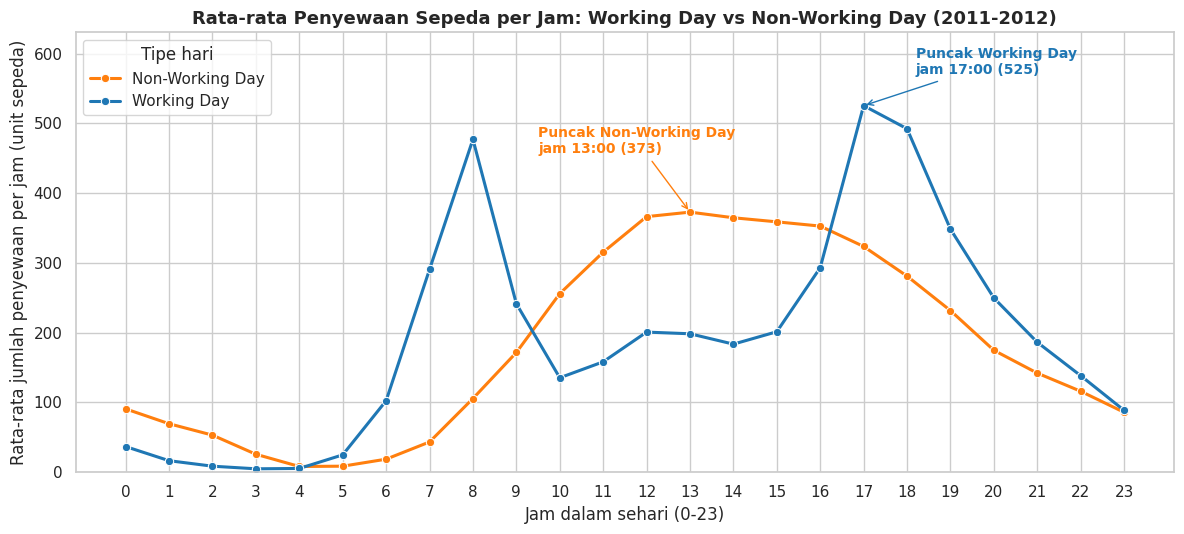

In [24]:
palette_day = {'Working Day': '#1f77b4', 'Non-Working Day': '#ff7f0e'}

fig, ax = plt.subplots(figsize=(12, 5.5))
sns.lineplot(data=df, x='hr', y='cnt', hue='day_type', estimator='mean', errorbar=None,
             marker='o', linewidth=2.2, palette=palette_day, ax=ax)

# Tandai jam puncak setiap tipe hari (dihitung dari data)
for day_type, color in palette_day.items():
    peak_hr = hourly[day_type].idxmax()
    peak_val = hourly[day_type].max()
    ax.annotate(f'Puncak {day_type}\njam {peak_hr:02d}:00 ({peak_val:.0f})',
                xy=(peak_hr, peak_val), xytext=(peak_hr + (1.2 if day_type == 'Working Day' else -3.5), peak_val + (45 if day_type == 'Working Day' else 85)),
                arrowprops=dict(arrowstyle='->', color=color), color=color, fontsize=10, fontweight='bold')

ax.set_title('Rata-rata Penyewaan Sepeda per Jam: Working Day vs Non-Working Day (2011-2012)', fontsize=13, fontweight='bold')
ax.set_xlabel('Jam dalam sehari (0-23)')
ax.set_ylabel('Rata-rata jumlah penyewaan per jam (unit sepeda)')
ax.set_xticks(range(24))
ax.set_ylim(0, hourly.max().max() * 1.2)
ax.legend(title='Tipe hari')
plt.tight_layout()
plt.show()

### Insight Business Question 1: Pola Jam Puncak Penyewaan Sepeda pada Working Day vs Non-Working Day

Berdasarkan grafik, **Working Day** memiliki pola dua puncak (*bimodal*): puncak pagi pada **jam 08:00 (rata-rata 477,0 sepeda/jam)** dan puncak sore yang lebih tinggi pada **jam 17:00 (525,3 sepeda/jam)**. Di antara kedua puncak, penyewaan turun tajam ke kisaran 135-201 sepeda/jam pada jam 10-15. Sebaliknya, **Non-Working Day** hanya memiliki satu puncak landai di siang hari (**jam 13:00, 372,7 sepeda/jam**) dan nyaris tidak ada aktivitas pada pagi hari (rata-rata blok 07-09 hanya 106,9).

Hal ini menunjukkan bahwa penyewaan hari kerja digerakkan oleh **perjalanan komuter**, sedangkan hari non-kerja digerakkan oleh **aktivitas rekreasi**, didukung pangsa pengguna *casual* 31,7% pada hari non-kerja vs 13,2% pada hari kerja.

Temuan ini menjawab pertanyaan bisnis karena menetapkan **jam kritis** yang harus diantisipasi operator: 07-09 dan 16-19 pada hari kerja, serta 10-16 pada hari non-kerja.

### Visualisasi Business Question 2: Dampak Cuaca Buruk dan Musim terhadap Penyewaan Sepeda

**Pertanyaan bisnis:** Berapa persen penurunan rata-rata penyewaan sepeda per jam pada kondisi cuaca buruk (*Mist/Cloudy* dan *Light Rain/Snow*) dibandingkan cuaca cerah, dan pada musim apa penurunan akibat hujan/salju paling besar, selama Januari 2011 – Desember 2012, sehingga operator dapat menyusun strategi promosi dan perawatan armada berdasarkan musim dan cuaca?

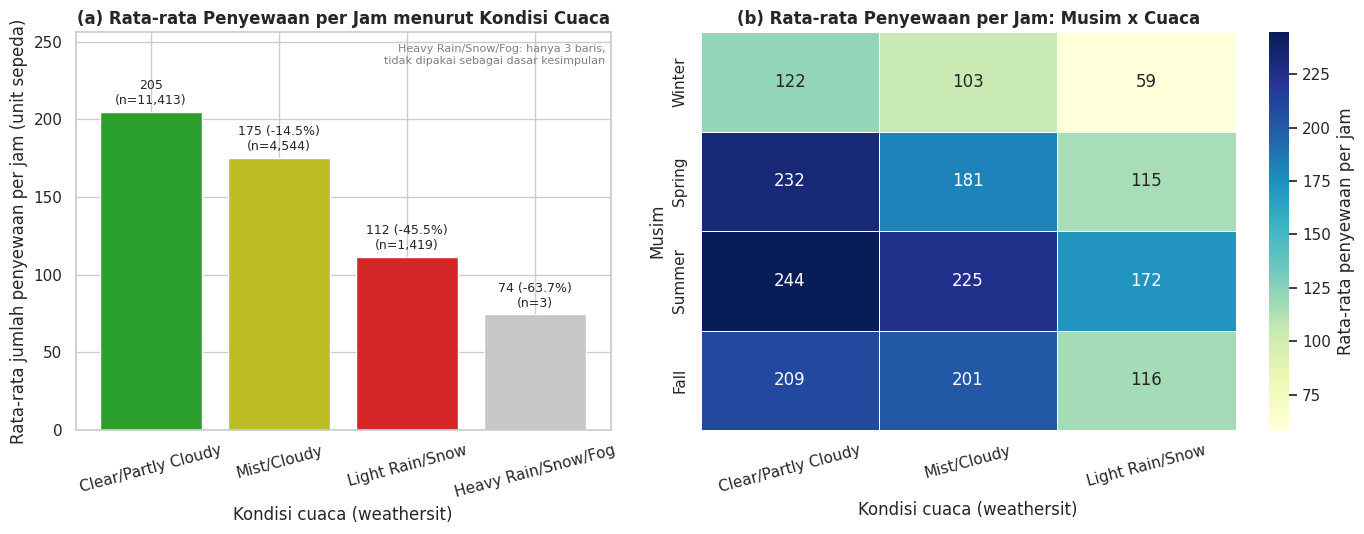

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), gridspec_kw={'width_ratios': [1, 1.25]})

# (a) Rata-rata per cuaca
plot_w = weather_stats.reset_index()
colors_w = ['#2ca02c', '#bcbd22', '#d62728', '#c7c7c7']
bars = axes[0].bar(plot_w['weather_label'].astype(str), plot_w['rata_rata'], color=colors_w)
for bar, n, pct in zip(bars, plot_w['jumlah_record'], plot_w['selisih_vs_clear_%']):
    label = f'{bar.get_height():.0f}\n(n={n:,})' if pct == 0 else f'{bar.get_height():.0f} ({pct:+.1f}%)\n(n={n:,})'
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3, label, ha='center', va='bottom', fontsize=9)
axes[0].set_title('(a) Rata-rata Penyewaan per Jam menurut Kondisi Cuaca', fontweight='bold')
axes[0].set_xlabel('Kondisi cuaca (weathersit)')
axes[0].set_ylabel('Rata-rata jumlah penyewaan per jam (unit sepeda)')
axes[0].set_ylim(0, plot_w['rata_rata'].max() * 1.25)
axes[0].tick_params(axis='x', labelrotation=15)
axes[0].text(0.99, 0.97, 'Heavy Rain/Snow/Fog: hanya 3 baris,\ntidak dipakai sebagai dasar kesimpulan',
             transform=axes[0].transAxes, ha='right', va='top', fontsize=8, color='gray')

# (b) Heatmap musim x cuaca
sns.heatmap(season_weather.loc[:, ['Clear/Partly Cloudy', 'Mist/Cloudy', 'Light Rain/Snow']], annot=True, fmt='.0f',
            cmap='YlGnBu', cbar_kws={'label': 'Rata-rata penyewaan per jam'}, linewidths=.5, ax=axes[1])
axes[1].set_title('(b) Rata-rata Penyewaan per Jam: Musim x Cuaca', fontweight='bold')
axes[1].set_xlabel('Kondisi cuaca (weathersit)')
axes[1].set_ylabel('Musim')
axes[1].tick_params(axis='x', labelrotation=15)

plt.tight_layout()
plt.show()

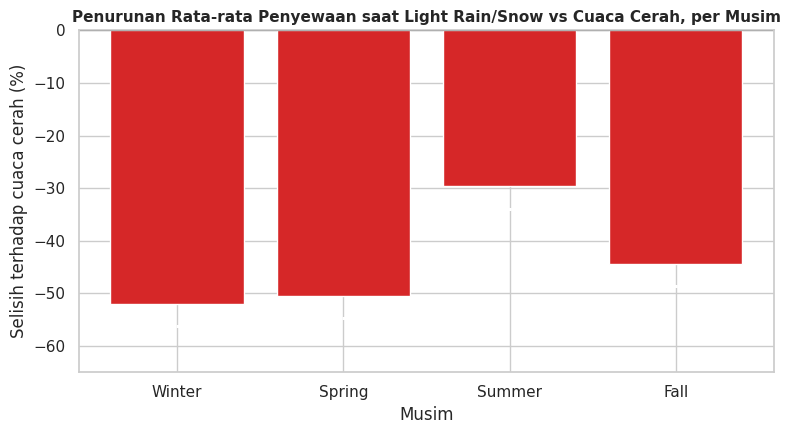

In [26]:
drop_plot = drop['Light Rain/Snow vs Clear %'].reset_index()
drop_plot.columns = ['season_label', 'drop_pct']
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(drop_plot['season_label'].astype(str), drop_plot['drop_pct'], color='#d62728')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() - 2, f'{bar.get_height():.1f}%', ha='center', va='top', color='white', fontweight='bold')
ax.set_title('Penurunan Rata-rata Penyewaan saat Light Rain/Snow vs Cuaca Cerah, per Musim', fontweight='bold', fontsize=11)
ax.set_xlabel('Musim')
ax.set_ylabel('Selisih terhadap cuaca cerah (%)')
ax.set_ylim(-65, 0)
ax.axhline(0, color='black', linewidth=.8)
plt.tight_layout()
plt.show()

### Insight Business Question 2: Dampak Cuaca Buruk dan Musim terhadap Penyewaan Sepeda

Grafik (a) menunjukkan penyewaan turun bertahap seiring memburuknya cuaca: dari **204,9** sepeda/jam pada cuaca cerah menjadi **175,2** pada Mist/Cloudy (**turun sekitar 14,5%**) dan **111,6** pada Light Rain/Snow (**turun sekitar 45,5%**). Heatmap (b) dan grafik penurunan per musim menunjukkan dampak hujan/salju **paling besar pada Winter (sekitar -51,9%) dan Spring (sekitar -50,4%)**, lalu Fall (sekitar -44,4%), dan **paling kecil pada Summer (sekitar -29,7%)**. Pada kondisi terburuk (Winter + Light Rain/Snow), rata-rata hanya 58,7 sepeda/jam, jauh di bawah Summer + cuaca cerah (244,5).

Hal ini menunjukkan bahwa pengguna di musim hangat lebih toleran terhadap cuaca basah, sedangkan di musim dingin/semi hujan nyaris menghentikan separuh permintaan.

Temuan ini menjawab pertanyaan bisnis karena menghasilkan besaran penurunan (persentase) dan **musim paling rentan** (Winter dan Spring), yang menjadi dasar strategi promosi dan penjadwalan perawatan armada.

### Validasi Business Question 2: Hasil Per Jam (`hour_df`) vs Hasil Harian (`day_df`)

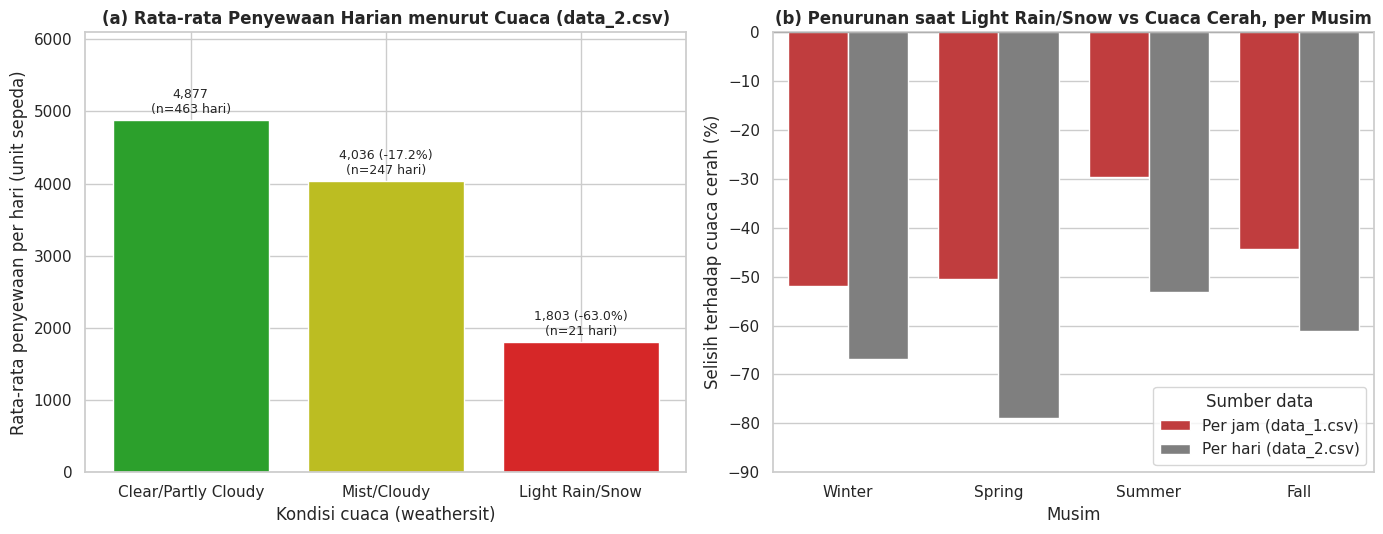

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# (a) Rata-rata harian per cuaca (day_df)
dw = daily_weather.reset_index()
bars = axes[0].bar(dw['weather_label'].astype(str), dw['rata_rata_harian'], color=['#2ca02c', '#bcbd22', '#d62728'])
for bar, n, pct in zip(bars, dw['jumlah_hari'], dw['selisih_vs_clear_%']):
    label = f'{bar.get_height():,.0f}\n(n={n} hari)' if pct == 0 else f'{bar.get_height():,.0f} ({pct:+.1f}%)\n(n={n} hari)'
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 60, label, ha='center', va='bottom', fontsize=9)
axes[0].set_title('(a) Rata-rata Penyewaan Harian menurut Cuaca (data_2.csv)', fontweight='bold')
axes[0].set_xlabel('Kondisi cuaca (weathersit)')
axes[0].set_ylabel('Rata-rata penyewaan per hari (unit sepeda)')
axes[0].set_ylim(0, dw['rata_rata_harian'].max() * 1.25)

# (b) Penurunan Light Rain/Snow per musim: perbandingan dua sumber
cmp_drop = pd.DataFrame({'Per jam (data_1.csv)': drop['Light Rain/Snow vs Clear %'],
                         'Per hari (data_2.csv)': daily_drop}).reset_index().melt(id_vars='season_label', var_name='Sumber', value_name='Selisih_%')
sns.barplot(data=cmp_drop, x='season_label', y='Selisih_%', hue='Sumber', palette=['#d62728', '#7f7f7f'], ax=axes[1])
axes[1].set_title('(b) Penurunan saat Light Rain/Snow vs Cuaca Cerah, per Musim', fontweight='bold')
axes[1].set_xlabel('Musim')
axes[1].set_ylabel('Selisih terhadap cuaca cerah (%)')
axes[1].set_ylim(-90, 0)
axes[1].axhline(0, color='black', linewidth=.8)
axes[1].legend(title='Sumber data', loc='lower right')

plt.tight_layout()
plt.show()

### Insight Validasi Business Question 2: Konsistensi Hasil Per Jam dan Harian

Kedua sumber data memberi kesimpulan yang searah: cuaca basah menekan penyewaan, dan dampaknya paling kecil pada **Summer** di kedua sumber (sekitar -29,7% per jam dan -53,2% per hari). Besaran persen pada data harian lebih besar karena yang diukur adalah total harian dan klasifikasi cuaca harian, bukan rata-rata per jam, jadi kedua angka dibaca sebagai **arah dan urutan musim**, bukan nilai yang harus sama. Pada data harian hanya ada 21 hari Light Rain/Snow, sehingga angka per musimnya perlu dibaca hati-hati. Validasi ini memperkuat jawaban BQ2.

## Analisis Lanjutan: Manual Grouping Tingkat Permintaan (Low, Medium, High Demand)

### Tujuan Analisis Lanjutan: Manual Grouping (Binning) Tingkat Permintaan

**Tujuan:** BQ1 dan BQ2 membandingkan rata-rata. Operator juga membutuhkan **kategori permintaan** yang mudah dipakai dalam keputusan harian, misalnya *kapan kondisi High Demand terjadi?* Karena itu setiap baris per jam dikelompokkan menjadi **Low / Medium / High Demand**.

**Metode (bukan Machine Learning):** *quantile binning* (tertile) pada `cnt`: bagian terbawah 1/3 data = **Low Demand**, 1/3 tengah = **Medium Demand**, 1/3 teratas = **High Demand**. Dipilih karena distribusi `cnt` miring ke kanan, sehingga batas ditentukan oleh persebaran data aktual, bukan angka yang dipilih sembarang. Batas hasilnya dicetak oleh Python di bawah.

Setelah pengelompokan, karakteristik tiap kategori dihubungkan dengan musim, cuaca, tipe hari, jam, suhu, dan kelembapan.

In [28]:
# Binning kuantil (tertile) pada cnt
df['demand_category'] = pd.qcut(df['cnt'], q=3, labels=['Low Demand', 'Medium Demand', 'High Demand'])

demand_order = ['Low Demand', 'Medium Demand', 'High Demand']
bounds = df.groupby('demand_category', observed=True)['cnt'].agg(batas_bawah='min', batas_atas='max', jumlah_baris='count', rata_rata_cnt='mean')
bounds['proporsi_%'] = bounds['jumlah_baris'] / len(df) * 100
print('Batas dan distribusi kategori (dari data):')
display(bounds.round(1))

profile = df.groupby('demand_category', observed=True).agg(
    rata2_suhu_C=('temp_c', 'mean'), rata2_kelembapan_pct=('hum_pct', 'mean'),
    rata2_kecepatan_angin=('wind_speed', 'mean'), rata2_jam=('hr', 'mean'))
print('\nProfil rata-rata tiap kategori:')
display(profile.round(2))

def pct_table(col):
    return (pd.crosstab(df[col], df['demand_category'], normalize='index') * 100).round(1)

print('\nKomposisi kategori (%) per musim:');       display(pct_table('season_label'))
print('Komposisi kategori (%) per cuaca:');          display(pct_table('weather_label'))
print('Komposisi kategori (%) per tipe hari:');      display(pct_table('day_type'))

high_share_hr = (df.assign(is_high=df['demand_category'] == 'High Demand')
                   .pivot_table(index='hr', columns='day_type', values='is_high', aggfunc='mean') * 100)
for col in high_share_hr.columns:
    hrs = list(high_share_hr.index[high_share_hr[col] >= 50])
    print(f'Jam dengan >= 50% baris High Demand ({col}): {hrs}')

Batas dan distribusi kategori (dari data):


,batas_bawah,batas_atas,jumlah_baris,rata_rata_cnt,proporsi_%
demand_category,,,,,
Low Demand,1,70,5797,25.10,33.40
Medium Demand,71,225,5823,144.30,33.50
High Demand,226,977,5759,400.60,33.10



Profil rata-rata tiap kategori:


,rata2_suhu_C,rata2_kelembapan_pct,rata2_kecepatan_angin,rata2_jam
demand_category,,,,
Low Demand,16.76,71.44,11.44,6.36
Medium Demand,19.82,61.75,13.31,13.80
High Demand,24.57,55.14,13.45,14.49



Komposisi kategori (%) per musim:


...

Komposisi kategori (%) per cuaca:


demand_category,Low Demand,Medium Demand,High Demand
weather_label,,,
Clear/Partly Cloudy,30.90,32.40,36.70
Mist/Cloudy,33.20,36.80,30.00
Light Rain/Snow,53.30,31.90,14.80
Heavy Rain/Snow/Fog,66.70,33.30,0.00


Komposisi kategori (%) per tipe hari:


demand_category,Low Demand,Medium Demand,High Demand
day_type,,,
Non-Working Day,36.30,31.20,32.40
Working Day,32.00,34.60,33.50


Jam dengan >= 50% baris High Demand (Non-Working Day): [10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Jam dengan >= 50% baris High Demand (Working Day): [7, 8, 9, 16, 17, 18, 19, 20]


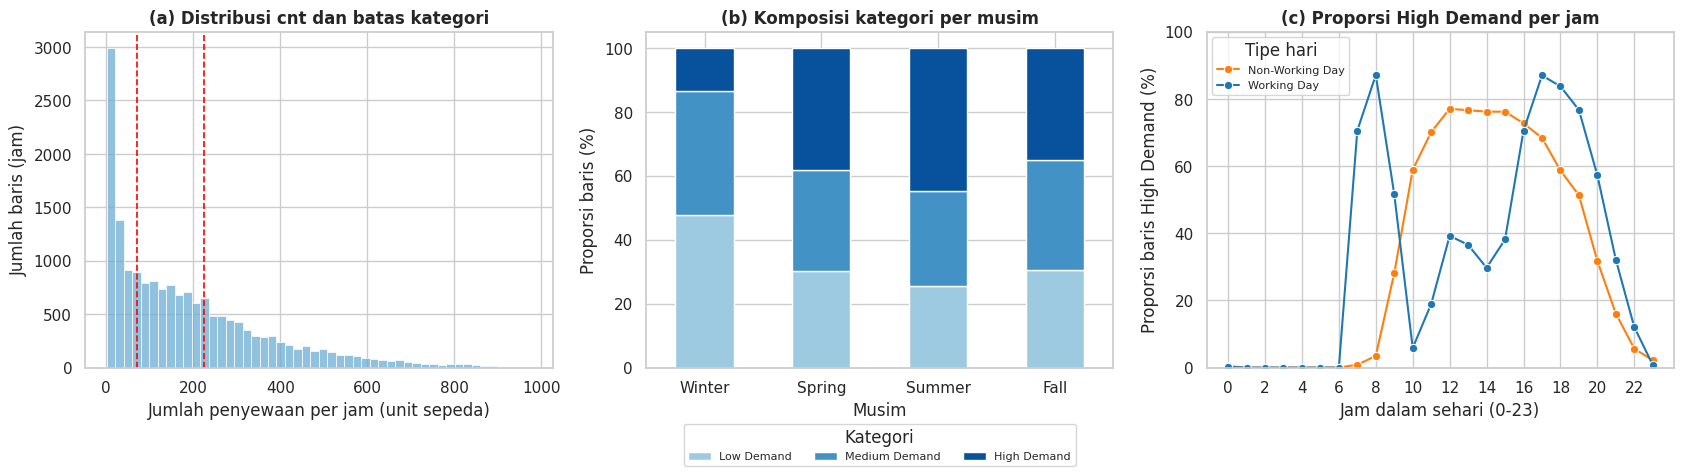

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
demand_colors = {'Low Demand': '#9ecae1', 'Medium Demand': '#4292c6', 'High Demand': '#08519c'}

# (a) Distribusi cnt dengan batas kategori
sns.histplot(df['cnt'], bins=50, color='#6baed6', ax=axes[0])
for b in bounds['batas_atas'].iloc[:2]:
    axes[0].axvline(b, color='red', linestyle='--', linewidth=1.2)
axes[0].set_title('(a) Distribusi cnt dan batas kategori', fontweight='bold')
axes[0].set_xlabel('Jumlah penyewaan per jam (unit sepeda)'); axes[0].set_ylabel('Jumlah baris (jam)')

# (b) Komposisi per musim
ct_s = pct_table('season_label')[demand_order]
ct_s.plot(kind='bar', stacked=True, color=[demand_colors[c] for c in demand_order], ax=axes[1], rot=0)
axes[1].set_title('(b) Komposisi kategori per musim', fontweight='bold')
axes[1].set_xlabel('Musim'); axes[1].set_ylabel('Proporsi baris (%)'); axes[1].legend(title='Kategori', fontsize=8, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)

# (c) Proporsi High Demand per jam
sns.lineplot(data=high_share_hr, dashes=False, palette=palette_day, marker='o', ax=axes[2])
axes[2].set_title('(c) Proporsi High Demand per jam', fontweight='bold')
axes[2].set_xlabel('Jam dalam sehari (0-23)'); axes[2].set_ylabel('Proporsi baris High Demand (%)')
axes[2].set_xticks(range(0, 24, 2)); axes[2].set_ylim(0, 100); axes[2].legend(title='Tipe hari', fontsize=8)

plt.tight_layout()
plt.show()

**Insight:**
- Batas tertile menghasilkan tiga kelompok seimbang (sekitar 5.800 jam per kategori): **Low Demand = 1-70**, **Medium Demand = 71-225**, **High Demand = 226-977 penyewaan per jam**.
- **High Demand** terjadi pada kondisi hangat dan kering: rata-rata suhu **24,6 C** dan kelembapan **55,1%**, dibanding Low Demand yang rata-rata **16,8 C** dan **71,4%**. Rata-rata jam kategori Low Demand adalah 6,4 (dini hari/pagi), sedangkan High Demand 14,5 (siang-sore).
- Per musim, **Summer paling banyak High Demand (44,8%)** dan **Winter paling sedikit (13,6%)**; Winter didominasi Low Demand (47,8%).
- Per cuaca, High Demand mencapai 36,7% pada cuaca cerah, turun menjadi 14,8% pada Light Rain/Snow, di mana Low Demand mendominasi (53,3%).
- Per jam, High Demand pada **Working Day** muncul di jam **07-09 dan 16-20**, sedangkan pada **Non-Working Day** di jam **10-19**. Hasil ini konsisten dengan BQ1 dan BQ2 dan memberi aturan praktis yang mudah dipakai operator.

### Menyimpan data bersih untuk dashboard

**Tujuan:** dashboard Streamlit memakai data hasil cleaning dan kategori yang sama persis dengan notebook, sehingga angka keduanya konsisten.

In [30]:
os.makedirs('dashboard', exist_ok=True)

main_cols = ['instant', 'dteday', 'year', 'mnth', 'hr', 'season', 'season_label', 'weathersit', 'weather_label',
             'workingday', 'day_type', 'day_name', 'holiday', 'temp_c', 'atemp_c', 'hum_pct', 'wind_speed',
             'casual', 'registered', 'cnt', 'demand_category']
main_data = df[main_cols].copy()
main_data['demand_category'] = main_data['demand_category'].astype(str)
main_data.to_csv('dashboard/main_data.csv', index=False)

print(f'main_data.csv tersimpan: {main_data.shape[0]:,} baris x {main_data.shape[1]} kolom')
print('Total cnt notebook:', int(main_data['cnt'].sum()))



main_data.csv tersimpan: 17,379 baris x 21 kolom
Total cnt notebook: 3292679


## Conclusion & Recommendation

### Conclusion

1. **Business Question 1 (Pola Jam Puncak Penyewaan Sepeda pada Working Day vs Non-Working Day):** Pada jam berapa rata-rata penyewaan sepeda per jam mencapai puncak pada *working day* dibandingkan *non-working day*, dan berapa rata-rata penyewaan pada jam puncak tersebut, selama periode Januari 2011 – Desember 2012, sehingga operator dapat menjadwalkan redistribusi dan ketersediaan sepeda pada jam-jam kritis?

   **Jawaban:** Pada **working day** penyewaan memuncak dua kali: **jam 17:00 (525,3 sepeda/jam, tertinggi)** dan **jam 08:00 (477,0)**, mengikuti pola komuter. Pada **non-working day** ada satu puncak landai pada **jam 13:00 (372,7)**, mengikuti pola rekreasi, dan pagi hari hampir sepi (rata-rata jam 07-09: 106,9 vs 336,4 pada hari kerja). Sekitar 57,9% penyewaan hari kerja terjadi pada jam 07-09 dan 16-19.

2. **Business Question 2 (Dampak Cuaca Buruk dan Musim terhadap Penyewaan Sepeda):** Berapa persen penurunan rata-rata penyewaan sepeda per jam pada kondisi cuaca buruk (*Mist/Cloudy* dan *Light Rain/Snow*) dibandingkan cuaca cerah, dan pada musim apa penurunan akibat hujan/salju paling besar, selama Januari 2011 – Desember 2012, sehingga operator dapat menyusun strategi promosi dan perawatan armada berdasarkan musim dan cuaca?

   **Jawaban:** Dibanding cuaca cerah (204,9 sepeda/jam), penyewaan turun sekitar **14,5%** pada Mist/Cloudy (175,2) dan sekitar **45,5%** pada Light Rain/Snow (111,6). Dampak hujan/salju **paling besar pada Winter (sekitar -51,9%) dan Spring (sekitar -50,4%)** dan paling kecil pada Summer (sekitar -29,7%). Secara musiman, Summer tertinggi (236,0) dan Winter terendah (111,1).

3. **Validasi silang dengan `data_2.csv`:** total harian identik dengan agregat per jam, dan analisis harian menghasilkan arah yang sama untuk BQ2 (cuaca cerah tertinggi; hujan/salju paling berdampak pada Winter dan Spring; Summer paling tahan).

4. **Analisis lanjutan (binning):** High Demand (226-977 sewa/jam) terkonsentrasi pada kondisi hangat dan kering (rata-rata 24,6 C, kelembapan 55,1%), pada Summer (44,8% baris High Demand) dan pada jam sibuk yang sama dengan temuan BQ1.

### Recommendation

**Rekomendasi Action Item** (diturunkan langsung dari temuan di atas):

1. **Redistribusi sepeda berbasis jam (dari BQ1).** Pada hari kerja, pastikan stok sepeda tersedia sebelum **jam 07:00** dan **jam 16:00** dan jadwalkan truk redistribusi pada jam 10-15 saat permintaan relatif rendah (jam 10-15 hanya sekitar 135-201 sepeda/jam). Pada akhir pekan/hari libur, fokuskan ketersediaan pada **jam 10-16**.
2. **Strategi promosi sesuai karakter pengguna (dari BQ1).** Karena pengguna *casual* mencapai 31,7% di hari non-kerja, arahkan promosi dan paket sewa singkat ke akhir pekan siang hari; untuk hari kerja, tawarkan paket keanggotaan komuter untuk memperkuat pengguna terdaftar pada jam 08:00 dan 17:00.
3. **Mitigasi cuaca (dari BQ2).** Saat prakiraan Light Rain/Snow, terutama di **Winter dan Spring** (penurunan sekitar 50%), kurangi jumlah sepeda di jalur operasional dan manfaatkan periode tersebut untuk **perawatan armada** terjadwal. Pada Summer penurunannya hanya sekitar 30%, sehingga kapasitas tetap perlu dijaga.
4. **Kapasitas musiman (dari analisis lanjutan).** High Demand mencapai 44,8% baris pada Summer vs 13,6% pada Winter; alokasikan armada penuh pada Summer dan Spring-Fall, serta lakukan promosi/insentif musim dingin untuk menaikkan permintaan di Winter.

**Catatan keterbatasan:** (a) 165 jam tidak tercatat di `data_1.csv` (kemungkinan jam tanpa penyewaan; total harian tetap cocok dengan `data_2.csv`), dan uji sensitivitas menunjukkan jam puncak tidak berubah; (b) perbandingan antar musim tercampur dengan tren pertumbuhan 2011 ke 2012; (c) kategori Heavy Rain/Snow/Fog hanya 3 baris sehingga tidak dijadikan dasar kesimpulan; (d) hasil bersifat deskriptif (asosiasi), bukan bukti sebab-akibat.